#Oil spill

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv('/content/drive/MyDrive/Data Mining Lab/oil-spill.csv', header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,1,2558,1506.09,456.63,90,6395000.0,40.88,7.89,29780.0,0.19,...,2850.00,1000.00,763.16,135.46,3.73,0,33243.19,65.74,7.95,1
1,2,22325,79.11,841.03,180,55812500.0,51.11,1.21,61900.0,0.02,...,5750.00,11500.00,9593.48,1648.80,0.60,0,51572.04,65.73,6.26,0
2,3,115,1449.85,608.43,88,287500.0,40.42,7.34,3340.0,0.18,...,1400.00,250.00,150.00,45.13,9.33,1,31692.84,65.81,7.84,1
3,4,1201,1562.53,295.65,66,3002500.0,42.40,7.97,18030.0,0.19,...,6041.52,761.58,453.21,144.97,13.33,1,37696.21,65.67,8.07,1
4,5,312,950.27,440.86,37,780000.0,41.43,7.03,3350.0,0.17,...,1320.04,710.63,512.54,109.16,2.58,0,29038.17,65.66,7.35,0


In [ ]:
# 0th column - patch number and 49th column - class label
df = data.drop([0,49], axis=1)
print(df.head())

      1        2       3    4           5      6     7        8     9      10  \
0   2558  1506.09  456.63   90   6395000.0  40.88  7.89  29780.0  0.19  214.7   
1  22325    79.11  841.03  180  55812500.0  51.11  1.21  61900.0  0.02  901.7   
2    115  1449.85  608.43   88    287500.0  40.42  7.34   3340.0  0.18   86.1   
3   1201  1562.53  295.65   66   3002500.0  42.40  7.97  18030.0  0.19  166.5   
4    312   950.27  440.86   37    780000.0  41.43  7.03   3350.0  0.17  232.8   

   ...  39       40        41       42       43     44  45        46     47  \
0  ...  69  2850.00   1000.00   763.16   135.46   3.73   0  33243.19  65.74   
1  ...  69  5750.00  11500.00  9593.48  1648.80   0.60   0  51572.04  65.73   
2  ...  69  1400.00    250.00   150.00    45.13   9.33   1  31692.84  65.81   
3  ...  69  6041.52    761.58   453.21   144.97  13.33   1  37696.21  65.67   
4  ...  69  1320.04    710.63   512.54   109.16   2.58   0  29038.17  65.66   

     48  
0  7.95  
1  6.26  
2  7.84 

In [ ]:
# • Identify columns that contain a single value
# single value - same value is present in that column for all rows

counts = df.nunique()
single_value_column = [i+1 for i, v in enumerate(counts) if v == 1]  #used i+1 because enumerate uses 0-indexing and the columns here starts from 1
print('Single value columns: ', single_value_column)

Single value columns:  [22]


In [ ]:
# • Delete columns that contain a single value

df_new_1 = df.drop(single_value_column, axis=1)
df_new_1.head()

,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
0,2558,1506.09,456.63,90,6395000.0,40.88,7.89,29780.0,0.19,214.7,...,69,2850.00,1000.00,763.16,135.46,3.73,0,33243.19,65.74,7.95
1,22325,79.11,841.03,180,55812500.0,51.11,1.21,61900.0,0.02,901.7,...,69,5750.00,11500.00,9593.48,1648.80,0.60,0,51572.04,65.73,6.26
2,115,1449.85,608.43,88,287500.0,40.42,7.34,3340.0,0.18,86.1,...,69,1400.00,250.00,150.00,45.13,9.33,1,31692.84,65.81,7.84
3,1201,1562.53,295.65,66,3002500.0,42.40,7.97,18030.0,0.19,166.5,...,69,6041.52,761.58,453.21,144.97,13.33,1,37696.21,65.67,8.07
4,312,950.27,440.86,37,780000.0,41.43,7.03,3350.0,0.17,232.8,...,69,1320.04,710.63,512.54,109.16,2.58,0,29038.17,65.66,7.35


In [1]:
# • Consider columns that have very few values

counts = df.nunique()

# columns that have very few unique values (considering threshold as 10)
few_values = [i+1 for i, v in enumerate(counts) if v < 10]
print(f"Columns with < 10 unique values: {few_values}")

NameError: name 'df' is not defined

In [ ]:
# • Remove columns that have a low variance

vars = df.var()

# columns that have a low variance (considering threshold as 0.1)
low_variance_column = [i+1 for i,v in enumerate(vars) if v < 0.1]
print(f"Columns with low variance: {low_variance_column}")

df_new_2 = df.drop(low_variance_column, axis=1)
df_new_2.head()

Columns with low variance: [9, 11, 12, 13, 14, 15, 19, 20, 22, 23, 30, 32, 36]


,1,2,3,4,5,6,7,8,10,16,...,39,40,41,42,43,44,45,46,47,48
0,2558,1506.09,456.63,90,6395000.0,40.88,7.89,29780.0,214.7,99.59,...,69,2850.00,1000.00,763.16,135.46,3.73,0,33243.19,65.74,7.95
1,22325,79.11,841.03,180,55812500.0,51.11,1.21,61900.0,901.7,6058.23,...,69,5750.00,11500.00,9593.48,1648.80,0.60,0,51572.04,65.73,6.26
2,115,1449.85,608.43,88,287500.0,40.42,7.34,3340.0,86.1,71.20,...,69,1400.00,250.00,150.00,45.13,9.33,1,31692.84,65.81,7.84
3,1201,1562.53,295.65,66,3002500.0,42.40,7.97,18030.0,166.5,120.22,...,69,6041.52,761.58,453.21,144.97,13.33,1,37696.21,65.67,8.07
4,312,950.27,440.86,37,780000.0,41.43,7.03,3350.0,232.8,289.19,...,69,1320.04,710.63,512.54,109.16,2.58,0,29038.17,65.66,7.35


In [ ]:
# • Identify rows that contain duplicate data

duplicate_rows_mask = df.duplicated()

duplicated_rows = [i for i,v in enumerate(duplicate_rows_mask) if v is True] #using i here since rows are 0-indexed in the df
print('Duplicated rows: ', duplicated_rows)

Duplicated rows:  []


In [ ]:
#  • Delete rows that contain duplicate data

df_new_3 = df.drop_duplicates()
df_new_3

,1,2,3,4,5,6,7,8,9,10,...,39,40,41,42,43,44,45,46,47,48
0,2558,1506.09,456.63,90,6395000.0,40.88,7.89,29780.0,0.19,214.7,...,69,2850.00,1000.00,763.16,135.46,3.73,0,33243.19,65.74,7.95
1,22325,79.11,841.03,180,55812500.0,51.11,1.21,61900.0,0.02,901.7,...,69,5750.00,11500.00,9593.48,1648.80,0.60,0,51572.04,65.73,6.26
2,115,1449.85,608.43,88,287500.0,40.42,7.34,3340.0,0.18,86.1,...,69,1400.00,250.00,150.00,45.13,9.33,1,31692.84,65.81,7.84
3,1201,1562.53,295.65,66,3002500.0,42.40,7.97,18030.0,0.19,166.5,...,69,6041.52,761.58,453.21,144.97,13.33,1,37696.21,65.67,8.07
4,312,950.27,440.86,37,780000.0,41.43,7.03,3350.0,0.17,232.8,...,69,1320.04,710.63,512.54,109.16,2.58,0,29038.17,65.66,7.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,12,92.42,364.42,135,97200.0,59.42,10.34,884.0,0.17,110.0,...,50,381.84,254.56,84.85,146.97,4.50,0,2593.50,65.85,6.39
933,11,98.82,248.64,159,89100.0,59.64,10.18,831.0,0.17,107.2,...,50,284.60,180.00,150.00,51.96,1.90,0,4361.25,65.70,6.53
934,14,25.14,428.86,24,113400.0,60.14,17.94,847.0,0.30,133.9,...,50,402.49,180.00,180.00,0.00,2.24,0,2153.05,65.91,6.12
935,10,96.00,451.30,68,81000.0,59.90,15.01,831.0,0.25,97.5,...,50,402.49,180.00,90.00,73.48,4.47,0,2421.43,65.97,6.32


# Cyber crime

In [ ]:
import pandas as pd
import numpy as np

motives = pd.read_csv('/content/drive/MyDrive/Data Mining Lab/IT_motives_2013.csv')
suspects = pd.read_csv('/content/drive/MyDrive/Data Mining Lab/IT_Suspect_2013.csv')

print("Cyber motives: \n", motives.head())
print("\nCyber suspects: \n", suspects.head())

Cyber motives: 
            State/UTs               Crime Head  Year  Revenge /Settling scores  \
0     Andhra Pradesh  Cyber Crimes By Motives  2013                         7   
1  Arunachal Pradesh  Cyber Crimes By Motives  2013                         0   
2              Assam  Cyber Crimes By Motives  2013                         0   
3              Bihar  Cyber Crimes By Motives  2013                         0   
4       Chhattisgarh  Cyber Crimes By Motives  2013                         0   

   Greed/ Money  Extortion  Cause Disrepute  \
0            63          0                0   
1             0          0                0   
2             0          0                0   
3           135          0                3   
4             0          2                0   

   Prank/ Satisfaction of Gaining Control   Fraud/ Illegal Gain  \
0                                        0                  219   
1                                        0                    0   
2           

Using the above dataset perform the following and interpret the results:

* If there are missing values in the data set, list the fields
having missing values. Use appropriate
method data imputation. (Note: The missing value represents the absence of the crime in a
particular time period.)

In [ ]:
# missing values in motives dataset
missing_val_column_motives = motives.columns[motives.isnull().any()]
print("Missing values in motives dataset: ", missing_val_column_motives)

# missing values in suspects dataset
missing_val_column_suspects = suspects.columns[suspects.isnull().any()]
print("Missing values in motives dataset: ", missing_val_column_suspects)

Missing values in motives dataset:  Index([], dtype='object')
Missing values in motives dataset:  Index([], dtype='object')


Merge both datasets based on the states and union territories. Use this merged dataset to perform the following:

i. Clean the dataset by removing the duplicate rows/columns

ii. Drop the column(s) in which there is/are no crime occurred.

iii. Identify the features containing unique values.

iv. Generate histograms to interpret the distribution of frequency of the different crime suspects.

v. Transform the features having a wide range of values using min-max normalization.

vi. Find the correlation between normalized values of the suspects and motives. List the motivation of the suspects in the increasing order of correlation. Visualize through heatmap the correlation. List the features having high correlation and no correlation.

vii. Use correlation, PCA and Regression methods on the dataset before and after normalization for feature selection. List the features that have been selected.

viii. Compare the features selected before and after normalization of data using PCA, Regression and correlation techniques.

In [ ]:
# Merge the dataset

# data = pd.merge(motives, suspects, left_on='State/UTs', right_on='State/ UTs')

motives.rename(columns={'State/UTs': 'State/UTs'}, inplace=True)
suspects.rename(columns={'State/ UTs': 'State/UTs'}, inplace=True)
data = pd.merge(motives, suspects, on='State/UTs')

print(data.info())
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   State/UTs                                38 non-null     object
 1   Crime Head_x                             38 non-null     object
 2   Year_x                                   38 non-null     int64 
 3   Revenge /Settling scores                 38 non-null     int64 
 4   Greed/ Money                             38 non-null     int64 
 5   Extortion                                38 non-null     int64 
 6   Cause Disrepute                          38 non-null     int64 
 7   Prank/ Satisfaction of Gaining Control   38 non-null     int64 
 8   Fraud/ Illegal Gain                      38 non-null     int64 
 9   Eve teasing/ Harassment                  38 non-null     int64 
 10  Others_x                                 38 non-null     int64 


,State/UTs,Crime Head_x,Year_x,Revenge /Settling scores,Greed/ Money,Extortion,Cause Disrepute,Prank/ Satisfaction of Gaining Control,Fraud/ Illegal Gain,Eve teasing/ Harassment,...,Total_x,Crime Head_y,Year_y,Foreign National /Group,Disgrunted Employee /Employee,Cracker/Student/ Professional learners,Business Competitor,Neighbours /Friends & Relatives,Others_y,Total_y
0,Andhra Pradesh,Cyber Crimes By Motives,2013,7,63,0,0,0,219,225,...,651,Cyber Crimes By Suspects,2013,19,12,196,15,75,334,651
1,Arunachal Pradesh,Cyber Crimes By Motives,2013,0,0,0,0,0,0,0,...,10,Cyber Crimes By Suspects,2013,0,0,0,0,0,10,10
2,Assam,Cyber Crimes By Motives,2013,0,0,0,0,0,0,0,...,154,Cyber Crimes By Suspects,2013,0,0,0,0,0,154,154
3,Bihar,Cyber Crimes By Motives,2013,0,135,0,3,0,0,0,...,139,Cyber Crimes By Suspects,2013,1,0,0,0,0,138,139
4,Chhattisgarh,Cyber Crimes By Motives,2013,0,0,2,0,0,4,17,...,101,Cyber Crimes By Suspects,2013,0,0,0,0,0,101,101
5,Goa,Cyber Crimes By Motives,2013,0,3,0,0,0,10,4,...,58,Cyber Crimes By Suspects,2013,0,2,1,0,2,53,58
6,Gujarat,Cyber Crimes By Motives,2013,2,16,0,2,0,7,12,...,77,Cyber Crimes By Suspects,2013,3,3,3,1,1,66,77
7,Haryana,Cyber Crimes By Motives,2013,0,44,0,0,0,1,18,...,323,Cyber Crimes By Suspects,2013,0,6,0,1,40,276,323
8,Himachal Pradesh,Cyber Crimes By Motives,2013,2,0,2,6,0,4,10,...,28,Cyber Crimes By Suspects,2013,0,0,6,0,14,8,28
9,Jammu and Kashmir,Cyber Crimes By Motives,2013,0,14,0,1,1,1,5,...,46,Cyber Crimes By Suspects,2013,0,0,3,0,0,43,46


In [ ]:
# i. Clean the dataset by removing the duplicate rows/columns

# Identify duplicate rows
row_duplicates_df = data[data.duplicated()]
print(f"Duplicate rows DataFrame (if any): \n{row_duplicates_df}")

# Identify redundant columns - Year_y is a duplicate of Year_x (since both the dataset has year 2013 only)
col_to_drop = ['Year_y']
print(f"Columns identified as redundant: {col_to_drop}")

# Drop duplicate rows
if not row_duplicates_df.empty:
  print("Dropping duplicate rows...")
  data.drop(row_duplicates_df.index, axis=0, inplace=True)
else:
  print("No duplicate rows found.")

# Drop redundant columns
if col_to_drop:
    print(f"Dropping column(s): {col_to_drop}")
    data.drop(columns=col_to_drop, inplace=True)
else:
    print("No redundant columns to drop.")

Duplicate rows DataFrame (if any): 
Empty DataFrame
Columns: [State/UTs, Crime Head_x, Year_x, Revenge /Settling scores, Greed/ Money, Extortion, Cause Disrepute, Prank/ Satisfaction of Gaining Control , Fraud/ Illegal Gain, Eve teasing/ Harassment, Others_x, Total_x, Crime Head_y, Year_y, Foreign National /Group, Disgrunted Employee /Employee, Cracker/Student/ Professional learners, Business Competitor, Neighbours /Friends & Relatives, Others_y, Total_y]
Index: []

[0 rows x 21 columns]
Columns identified as redundant: ['Year_y']
No duplicate rows found.
Dropping column(s): ['Year_y']


In [ ]:
# print(data[data.duplicated()])
dd = data.duplicated()
dd[0] = True
# dd
print(data[dd])

        State/UTs             Crime Head_x  Year_x  Revenge /Settling scores  \
0  Andhra Pradesh  Cyber Crimes By Motives    2013                         7   

   Greed/ Money  Extortion  Cause Disrepute  \
0            63          0                0   

   Prank/ Satisfaction of Gaining Control   Fraud/ Illegal Gain  \
0                                        0                  219   

   Eve teasing/ Harassment  Others_x  Total_x              Crime Head_y  \
0                      225       137      651  Cyber Crimes By Suspects   

   Foreign National /Group  Disgrunted Employee /Employee  \
0                       19                             12   

   Cracker/Student/ Professional learners  Business Competitor  \
0                                     196                   15   

   Neighbours /Friends & Relatives  Others_y  Total_y  
0                               75       334      651  


In [ ]:
# rename the columns in the merged df (if needed)

data.rename(columns={'Year_x': 'Year'}, inplace=True)
data.rename(columns={'Others_x': 'Others_motives'}, inplace=True)
data.rename(columns={'Others_y': 'Others_suspects'}, inplace=True)
data.rename(columns={'Total_x': 'Total_motives'}, inplace=True)
data.rename(columns={'Total_y': 'Total_suspects'}, inplace=True)
data.rename(columns={'Crime Head_x': 'Crime Head_motives'}, inplace=True)
data.rename(columns={'Crime Head_y': 'Crime Head_suspects'}, inplace=True)

print(data.info())
data


# data.rename(columns={
#     'Year_x': 'Year',
#     'Others_x': 'Others_motives',
#     'Others_y': 'Others_suspects',
#     'Total_x': 'Total_motives',
#     'Total_y': 'Total_suspects',
#     'Crime Head_x': 'Crime Head_motives',
#     'Crime Head_y': 'Crime Head_suspects'
# }, inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 20 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   State/UTs                                38 non-null     object
 1   Crime Head_motives                       38 non-null     object
 2   Year                                     38 non-null     int64 
 3   Revenge /Settling scores                 38 non-null     int64 
 4   Greed/ Money                             38 non-null     int64 
 5   Extortion                                38 non-null     int64 
 6   Cause Disrepute                          38 non-null     int64 
 7   Prank/ Satisfaction of Gaining Control   38 non-null     int64 
 8   Fraud/ Illegal Gain                      38 non-null     int64 
 9   Eve teasing/ Harassment                  38 non-null     int64 
 10  Others_motives                           38 non-null     int64 


,State/UTs,Crime Head_motives,Year,Revenge /Settling scores,Greed/ Money,Extortion,Cause Disrepute,Prank/ Satisfaction of Gaining Control,Fraud/ Illegal Gain,Eve teasing/ Harassment,Others_motives,Total_motives,Crime Head_suspects,Foreign National /Group,Disgrunted Employee /Employee,Cracker/Student/ Professional learners,Business Competitor,Neighbours /Friends & Relatives,Others_suspects,Total_suspects
0,Andhra Pradesh,Cyber Crimes By Motives,2013,7,63,0,0,0,219,225,137,651,Cyber Crimes By Suspects,19,12,196,15,75,334,651
1,Arunachal Pradesh,Cyber Crimes By Motives,2013,0,0,0,0,0,0,0,10,10,Cyber Crimes By Suspects,0,0,0,0,0,10,10
2,Assam,Cyber Crimes By Motives,2013,0,0,0,0,0,0,0,154,154,Cyber Crimes By Suspects,0,0,0,0,0,154,154
3,Bihar,Cyber Crimes By Motives,2013,0,135,0,3,0,0,0,1,139,Cyber Crimes By Suspects,1,0,0,0,0,138,139
4,Chhattisgarh,Cyber Crimes By Motives,2013,0,0,2,0,0,4,17,78,101,Cyber Crimes By Suspects,0,0,0,0,0,101,101
5,Goa,Cyber Crimes By Motives,2013,0,3,0,0,0,10,4,41,58,Cyber Crimes By Suspects,0,2,1,0,2,53,58
6,Gujarat,Cyber Crimes By Motives,2013,2,16,0,2,0,7,12,38,77,Cyber Crimes By Suspects,3,3,3,1,1,66,77
7,Haryana,Cyber Crimes By Motives,2013,0,44,0,0,0,1,18,260,323,Cyber Crimes By Suspects,0,6,0,1,40,276,323
8,Himachal Pradesh,Cyber Crimes By Motives,2013,2,0,2,6,0,4,10,4,28,Cyber Crimes By Suspects,0,0,6,0,14,8,28
9,Jammu and Kashmir,Cyber Crimes By Motives,2013,0,14,0,1,1,1,5,24,46,Cyber Crimes By Suspects,0,0,3,0,0,43,46


In [ ]:
# ii. Drop the column(s) in which there is/are no crime occurred.

excluded_cols = ['State/UTs', 'Crime Head_motives', 'Year', 'Crime Head_suspects']
columns = [col for col in data.columns if col not in excluded_cols]

# Identify columns where all values are zero (no crime occurred)
cols_to_drop = []
for col in columns:
    if (data[col] == 0).all():
        cols_to_drop.append(col)

print(f"Columns with no crime occurred (all zeros): {cols_to_drop}")

# Drop these identified columns
if cols_to_drop:
    data.drop(columns=cols_to_drop, inplace=True)
    print(f"Dropped columns: {cols_to_drop}")
else:
    print("No columns found with no crime occurred (all zeros).")

data.head()

Columns with no crime occurred (all zeros): []
No columns found with no crime occurred (all zeros).


,State/UTs,Crime Head_motives,Year,Revenge /Settling scores,Greed/ Money,Extortion,Cause Disrepute,Prank/ Satisfaction of Gaining Control,Fraud/ Illegal Gain,Eve teasing/ Harassment,Others_motives,Total_motives,Crime Head_suspects,Foreign National /Group,Disgrunted Employee /Employee,Cracker/Student/ Professional learners,Business Competitor,Neighbours /Friends & Relatives,Others_suspects,Total_suspects
0,Andhra Pradesh,Cyber Crimes By Motives,2013,7,63,0,0,0,219,225,137,651,Cyber Crimes By Suspects,19,12,196,15,75,334,651
1,Arunachal Pradesh,Cyber Crimes By Motives,2013,0,0,0,0,0,0,0,10,10,Cyber Crimes By Suspects,0,0,0,0,0,10,10
2,Assam,Cyber Crimes By Motives,2013,0,0,0,0,0,0,0,154,154,Cyber Crimes By Suspects,0,0,0,0,0,154,154
3,Bihar,Cyber Crimes By Motives,2013,0,135,0,3,0,0,0,1,139,Cyber Crimes By Suspects,1,0,0,0,0,138,139
4,Chhattisgarh,Cyber Crimes By Motives,2013,0,0,2,0,0,4,17,78,101,Cyber Crimes By Suspects,0,0,0,0,0,101,101


In [ ]:
# Identify the features containing unique values.

unique_value_cols = [col for col in data.columns if data[col].nunique() == 1]

print('Columns with unique values: \n', unique_value_cols)

Columns with unique values: 
 ['Crime Head_motives', 'Year', 'Crime Head_suspects']


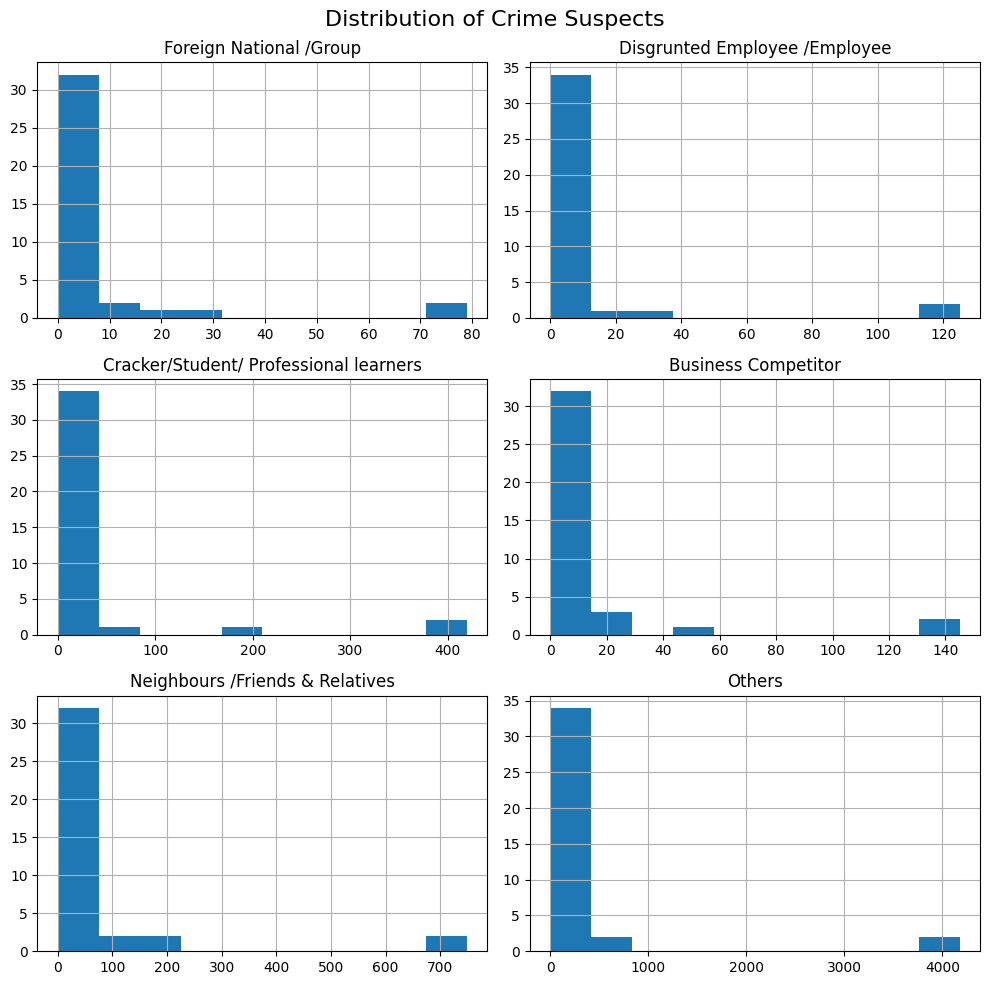

In [ ]:
# iv. Generate histograms to interpret the distribution of frequency of the different crime suspects.
import matplotlib.pyplot as plt

crime_suspects = suspects.drop(['State/UTs','Year','Crime Head', 'Total'], axis=1)
crime_suspects.hist(figsize=(10,10))
plt.suptitle("Distribution of Crime Suspects", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# v. Transform the features having a wide range of values using min-max normalization.
from sklearn.preprocessing import MinMaxScaler

excluded_cols = ['State/UTs', 'Crime Head_motives', 'Year', 'Crime Head_suspects', 'Crime Head_motives']
columns = [col for col in data.columns if col not in excluded_cols]
df = data.copy()

for col in columns:
  df[col] = MinMaxScaler().fit_transform(df[col].values.reshape(-1,1))

df

,State/UTs,Crime Head_motives,Year,Revenge /Settling scores,Greed/ Money,Extortion,Cause Disrepute,Prank/ Satisfaction of Gaining Control,Fraud/ Illegal Gain,Eve teasing/ Harassment,Others_motives,Total_motives,Crime Head_suspects,Foreign National /Group,Disgrunted Employee /Employee,Cracker/Student/ Professional learners,Business Competitor,Neighbours /Friends & Relatives,Others_suspects,Total_suspects
0,Andhra Pradesh,Cyber Crimes By Motives,2013,0.062500,0.076736,0.000000,0.000000,0.000000,0.176613,0.201613,0.063899,0.114351,Cyber Crimes By Suspects,0.240506,0.096,0.466667,0.103448,0.100134,0.080000,0.114351
1,Arunachal Pradesh,Cyber Crimes By Motives,2013,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004664,0.001757,Cyber Crimes By Suspects,0.000000,0.000,0.000000,0.000000,0.000000,0.002395,0.001757
2,Assam,Cyber Crimes By Motives,2013,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.071828,0.027051,Cyber Crimes By Suspects,0.000000,0.000,0.000000,0.000000,0.000000,0.036886,0.027051
3,Bihar,Cyber Crimes By Motives,2013,0.000000,0.164434,0.000000,0.020270,0.000000,0.000000,0.000000,0.000466,0.024416,Cyber Crimes By Suspects,0.012658,0.000,0.000000,0.000000,0.000000,0.033054,0.024416
4,Chhattisgarh,Cyber Crimes By Motives,2013,0.000000,0.000000,0.027397,0.000000,0.000000,0.003226,0.015233,0.036381,0.017741,Cyber Crimes By Suspects,0.000000,0.000,0.000000,0.000000,0.000000,0.024192,0.017741
5,Goa,Cyber Crimes By Motives,2013,0.000000,0.003654,0.000000,0.000000,0.000000,0.008065,0.003584,0.019123,0.010188,Cyber Crimes By Suspects,0.000000,0.016,0.002381,0.000000,0.002670,0.012695,0.010188
6,Gujarat,Cyber Crimes By Motives,2013,0.017857,0.019488,0.000000,0.013514,0.000000,0.005645,0.010753,0.017724,0.013525,Cyber Crimes By Suspects,0.037975,0.024,0.007143,0.006897,0.001335,0.015808,0.013525
7,Haryana,Cyber Crimes By Motives,2013,0.000000,0.053593,0.000000,0.000000,0.000000,0.000806,0.016129,0.121269,0.056736,Cyber Crimes By Suspects,0.000000,0.048,0.000000,0.006897,0.053405,0.066108,0.056736
8,Himachal Pradesh,Cyber Crimes By Motives,2013,0.017857,0.000000,0.027397,0.040541,0.000000,0.003226,0.008961,0.001866,0.004918,Cyber Crimes By Suspects,0.000000,0.000,0.014286,0.000000,0.018692,0.001916,0.004918
9,Jammu and Kashmir,Cyber Crimes By Motives,2013,0.000000,0.017052,0.000000,0.006757,0.025641,0.000806,0.004480,0.011194,0.008080,Cyber Crimes By Suspects,0.000000,0.000,0.007143,0.000000,0.000000,0.010299,0.008080


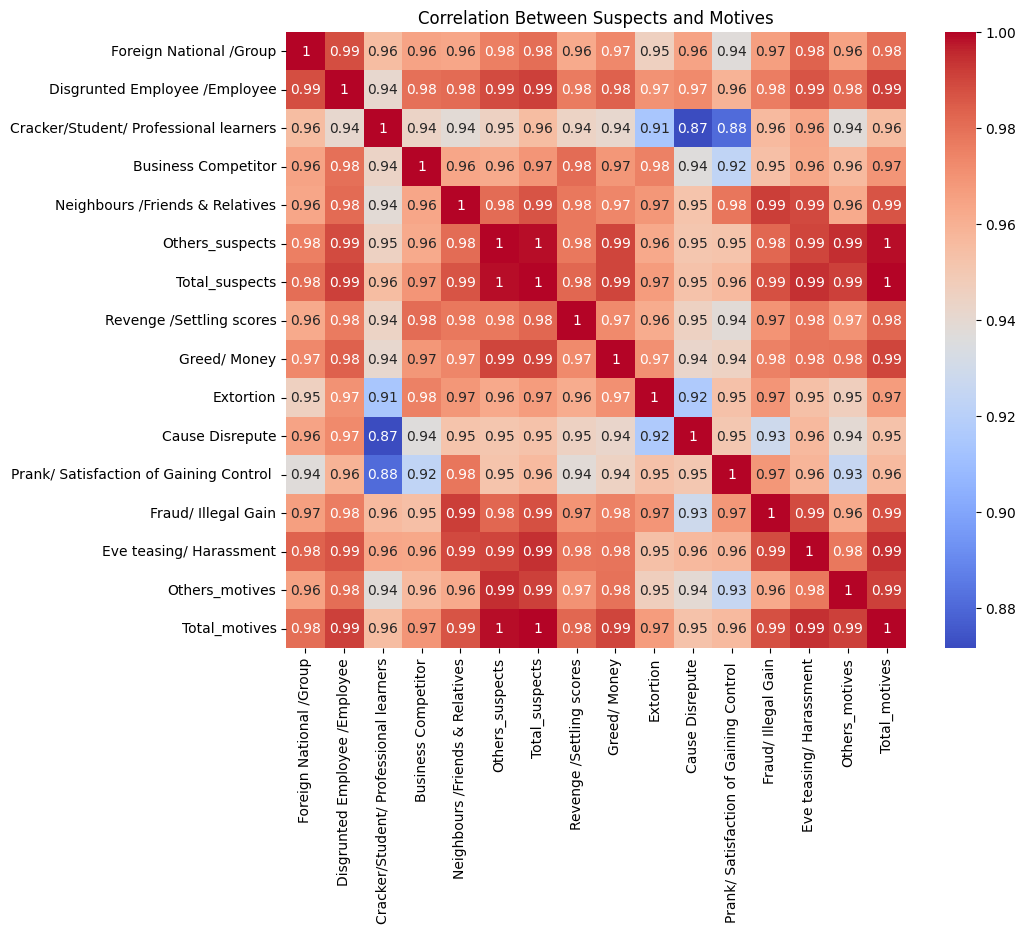

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

exclude_cols = ['State/UTs', 'Crime Head', 'Year']

scaler = MinMaxScaler()

suspects_df_dropped = suspects.drop(columns=exclude_cols)
suspects_df_dropped.rename(columns={'Others':'Others_suspects', 'Total':'Total_suspects'}, inplace=True)

suspects_norm = pd.DataFrame(
    scaler.fit_transform(suspects_df_dropped),
    columns=suspects_df_dropped.columns
)

motives_df_dropped = motives.drop(columns=exclude_cols)
motives_df_dropped.rename(columns={'Others':'Others_motives', 'Total':'Total_motives'}, inplace=True)

motives_norm = pd.DataFrame(
    scaler.fit_transform(motives_df_dropped),
    columns=motives_df_dropped.columns
)

# correlation
combined = pd.concat([suspects_norm, motives_norm], axis=1)
corr_all = combined.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_all, annot=True, cmap='coolwarm')
plt.title("Correlation Between Suspects and Motives")
plt.show()

In [ ]:
# vii. Use correlation, PCA and Regression methods on the dataset before and after normalization for feature selection. List the features that have been selected.
# viii. Compare the features selected before and after normalization of data using PCA, Regression and correlation techniques.

# correlation
combined_before_norm = pd.concat([suspects_df_dropped, motives_df_dropped], axis=1)
corr_before = combined_before_norm.corr()

combined_after_norm = pd.concat([suspects_norm, motives_norm], axis=1)
corr_after = combined_after_norm.corr()

print("\nTop Correlated Features with Total_suspects (Before Normalization) [Top 5]:")
print(corr_before["Total_suspects"].sort_values(ascending=False)[:5])

print("\nTop Correlated Features with Total_suspects (After Normalization) [Top 5]:")
print(corr_after["Total_suspects"].sort_values(ascending=False)[:5])


Top Correlated Features with Total_suspects (Before Normalization) [Top 5]:
Total_suspects             1.000000
Total_motives              1.000000
Others_suspects            0.998924
Eve teasing/ Harassment    0.994428
Others_motives             0.991392
Name: Total_suspects, dtype: float64

Top Correlated Features with Total_suspects (After Normalization) [Top 5]:
Total_suspects             1.000000
Total_motives              1.000000
Others_suspects            0.998924
Eve teasing/ Harassment    0.994428
Others_motives             0.991392
Name: Total_suspects, dtype: float64


In [ ]:
# PCA
from sklearn.decomposition import PCA
import numpy as np

pca_before_norm = PCA(n_components=5)
pca_before_norm.fit(combined_before_norm)

pca_after_norm = PCA(n_components=5)
pca_after_norm.fit(combined_after_norm)

feature_names = combined_before_norm.columns

def get_top_pca_features(pca, feature_names, top_k=5):
    loadings = np.abs(pca.components_)
    importance = loadings.sum(axis=0)
    top_indices = np.argsort(importance)[::-1][:top_k]
    return feature_names[top_indices]

top_pca_before = get_top_pca_features(pca_before_norm, feature_names, 5)
top_pca_after  = get_top_pca_features(pca_after_norm, feature_names, 5)

print("\nTop 5 PCA Features (Before Normalization):")
print(top_pca_before)

print("\nTop 5 PCA Features (After Normalization):")
print(top_pca_after)


Top 5 PCA Features (Before Normalization):
Index(['Fraud/ Illegal Gain', 'Others_motives', 'Others_suspects',
       'Cracker/Student/ Professional learners', 'Eve teasing/ Harassment'],
      dtype='object')

Top 5 PCA Features (After Normalization):
Index(['Cracker/Student/ Professional learners', 'Cause Disrepute',
       'Prank/ Satisfaction of Gaining Control ', 'Extortion',
       'Business Competitor'],
      dtype='object')


In [ ]:
# regression
from sklearn.linear_model import LinearRegression

target = "Total_suspects"

X_before = combined_before_norm.drop(columns=[target])
y = combined_before_norm[target]

X_after = combined_after_norm.drop(columns=[target])

lr_before = LinearRegression().fit(X_before, y)
lr_after = LinearRegression().fit(X_after, y)

def get_top_regression_features(model, feature_names, top_k=5):
    coef = np.abs(model.coef_)
    top_idx = np.argsort(coef)[::-1][:top_k]
    return feature_names[top_idx]

top_reg_before = get_top_regression_features(lr_before, X_before.columns, 5)
top_reg_after = get_top_regression_features(lr_after, X_after.columns, 5)

print("Top Regression Features (Before Norm):\n", top_reg_before)
print("\nTop Regression Features (After Norm):\n", top_reg_after)

Top Regression Features (Before Norm):
 Index(['Total_motives', 'Business Competitor',
       'Cracker/Student/ Professional learners', 'Others_suspects',
       'Neighbours /Friends & Relatives'],
      dtype='object')

Top Regression Features (After Norm):
 Index(['Others_motives', 'Others_suspects', 'Total_motives',
       'Fraud/ Illegal Gain', 'Eve teasing/ Harassment'],
      dtype='object')
